# CS224N 作业 1：探索词向量（25 分）
### <font color='blue'> 截止时间：2026 年 1 月 13 日周二下午 4:30</font>


欢迎学习 CS224N！

开始之前，请务必**阅读与本 notebook 同目录下的 README.md** 以了解重要的环境配置说明。你需要先安装一些 Python 库才能顺利完成本作业。本 notebook 中提供了大量代码，强烈建议你阅读并理解它们，这也是学习的一部分 :)

如果你对 Python、Numpy 或 Matplotlib 不太熟悉，建议参加周五的复习课。课程会录制并在我方 [网站](http://web.stanford.edu/class/cs224n/index.html#schedule) 提供资料。CS231N 的 Python/Numpy [教程](https://cs231n.github.io/python-numpy-tutorial/) 也是很好的参考。


**作业说明：** 请随时保存 notebook。提交说明在 notebook 末尾。

In [1]:
# All Import Statements Defined Here
# Note: Do not add to this list.
# ----------------

import sys
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 8

from platform import python_version
assert int(python_version().split(".")[1]) >= 5, "Please upgrade your Python version following the instructions in \
    the README.md file found in the same directory as this notebook. Your Python version is " + python_version()

from gensim.models import KeyedVectors
from gensim.test.utils import datapath
import pprint
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

from datasets import load_dataset
imdb_dataset = load_dataset("stanfordnlp/imdb", name="plain_text")

import re
import numpy as np
import random
import scipy as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

START_TOKEN = '<START>'
END_TOKEN = '<END>'

NUM_SAMPLES = 150

np.random.seed(0)
random.seed(0)
# ----------------

## 词向量

词向量常作为下游 NLP 任务（如问答、文本生成、翻译等）的基础组件，因此了解其优缺点很重要。本作业中你将探索两类词向量：由*共现矩阵*得到的，以及由 *GloVe* 得到的。

**术语说明：** “词向量”与“词嵌入”常可互换使用。“嵌入”一词指我们将词义的各方面编码到更低维的空间中。如 [维基百科](https://en.wikipedia.org/wiki/Word_embedding) 所述：“*从概念上讲，它涉及从‘每个词一维’的空间到维度更低的连续向量空间的数学嵌入*”。.

## 第一部分：基于计数的词向量（10 分）

多数词向量模型源于以下思想：

*知词莫若其伴（[Firth, J. R. 1957:11](https://en.wikipedia.org/wiki/John_Rupert_Firth)）*

许多词向量实现基于这样的想法：相似词（即近义词）会在相似上下文中出现，因此相似词往往会与一组共同的词（即上下文）一起出现。通过分析这些上下文，我们可以为词构建嵌入。在这种直觉下，很多“传统”方法用词计数来构建词向量。这里我们详述其中一种策略：*共现矩阵*（更多信息见 [这里](https://web.stanford.edu/~jurafsky/slp3/6.pdf) 或 [这里](https://web.archive.org/web/20190530091127/https://medium.com/data-science-group-iitr/word-embedding-2d05d270b285)）。

### 共现

共现矩阵统计事物在某一环境中共同出现的频率。给定文档中出现的词 $w_i$，我们考虑 $w_i$ 周围的*上下文窗口*。设固定窗口大小为 $n$，则该窗口由该文档中 $w_i$ 前 $n$ 个词与后 $n$ 个词组成，即 $w_{i-n} \dots w_{i-1}$ 与 $w_{i+1} \dots w_{i+n}$。我们构建*共现矩阵* $M$：一个对称的词×词矩阵，其中 $M_{ij}$ 表示在所有文档中 $w_j$ 出现在 $w_i$ 窗口内的次数。

**示例：固定窗口 n=1 的共现**：

文档 1："all that glitters is not gold"

文档 2："all is well that ends well"


|     *    | `<START>` | all | that | glitters | is   | not  | gold  | well | ends | `<END>` |
|----------|-------|-----|------|----------|------|------|-------|------|------|-----|
| `<START>`    | 0     | 2   | 0    | 0        | 0    | 0    | 0     | 0    | 0    | 0   |
| all      | 2     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| that     | 0     | 1   | 0    | 1        | 0    | 0    | 0     | 1    | 1    | 0   |
| glitters | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| is       | 0     | 1   | 0    | 1        | 0    | 1    | 0     | 1    | 0    | 0   |
| not      | 0     | 0   | 0    | 0        | 1    | 0    | 1     | 0    | 0    | 0   |
| gold     | 0     | 0   | 0    | 0        | 0    | 1    | 0     | 0    | 0    | 1   |
| well     | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 1    | 1   |
| ends     | 0     | 0   | 1    | 0        | 0    | 0    | 0     | 1    | 0    | 0   |
| `<END>`      | 0     | 0   | 0    | 0        | 0    | 0    | 1     | 1    | 0    | 0   |

在 NLP 中常用 `<START>` 和 `<END>` 标记句、段或文档的首尾。这些标记会参与共现统计，例如文档可写为："`<START>` All that glitters is not gold `<END>`"。

矩阵的行（或列）给出基于词-词共现的词向量，但维度可能很大。为降维，我们使用奇异值分解（SVD），类似 PCA，选取前 $k$ 个主成分。SVD 将共现矩阵 $A$ 分解为对角阵 $S$ 中的奇异值以及 $U_k$ 中新的、更短的词向量。

这种降维能保留语义关系；例如 *doctor* 与 *hospital* 会比 *doctor* 与 *dog* 更接近。

不熟悉特征值与 SVD 的读者可参考 [这份入门教程](https://davetang.org/file/Singular_Value_Decomposition_Tutorial.pdf)。CS168 的 [第 7](https://web.stanford.edu/class/cs168/l/l7.pdf)、[8](http://theory.stanford.edu/~tim/s15/l/l8.pdf)、[9](https://web.stanford.edu/class/cs168/l/l9.pdf) 讲对算法有更高层次的讲解。实现时建议使用 numpy、scipy 或 sklearn 等库中现成的函数。对大语料做完整 SVD 可能很占内存，可使用 Truncated SVD 等可扩展方法高效提取前 $k$ 个向量成分。

### 绘制共现词嵌入

这里我们使用 Large Movie Review 数据集。该数据集用于二分类情感分类，数据量远大于以往基准。我们提供 25,000 条极性强影评用于训练、25,000 条用于测试，另有未标注数据可用。下面提供的 `read_corpus` 函数会从数据集中取出影评文本，并为每条文档添加 `<START>` 和 `<END>` 标记并将词转为小写。你**不需要**做其他预处理。

In [2]:
def read_corpus():
    """ Read files from the Large Movie Review Dataset.
        Params:
            category (string): category name
        Return:
            list of lists, with words from each of the processed files
    """
    files = imdb_dataset["train"]["text"][:NUM_SAMPLES]
    return [[START_TOKEN] + [re.sub(r'[^\w]', '', w.lower()) for w in f.split(" ")] + [END_TOKEN] for f in files]

来看一下这些文档长什么样….

In [3]:
imdb_corpus = read_corpus()
pprint.pprint(imdb_corpus[:3], compact=True, width=100)
print("corpus size: ", len(imdb_corpus[0]))

[['<START>', 'i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because',
  'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first',
  'released', 'in', '1967', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized',
  'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore',
  'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to',
  'see', 'this', 'for', 'myselfbr', 'br', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young',
  'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything',
  'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her',
  'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average',
  'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam',
  'war', 'and', 'race', 'issu

### 题目 1.1：实现 `distinct_words` [代码]（2 分）

编写一个方法，统计语料中出现的不同词（词型）。

你可以用 `for` 循环处理输入 `corpus`（字符串的列表的列表），但建议尝试使用 Python 列表推导式（通常更快）。[这里](https://coderwall.com/p/rcmaea/flatten-a-list-of-lists-in-one-line-in-python) 介绍如何一行代码展平列表的列表。若不熟悉列表推导式，可参考 [更多说明](https://python-3-patterns-idioms-test.readthedocs.io/en/latest/Comprehensions.html)。

返回的 `corpus_words` 应为已排序的。可使用 Python 的 `sorted` 函数。

使用 [Python 集合](https://www.w3schools.com/python/python_sets.asp) 去重会很有帮助。

In [9]:
def distinct_words(corpus):
    """ Determine a list of distinct words for the corpus.
        Params:
            corpus (list of list of strings): corpus of documents
        Return:
            corpus_words (list of strings): sorted list of distinct words across the corpus
            n_corpus_words (integer): number of distinct words across the corpus
    """
    corpus_words = []
    n_corpus_words = -1
    for i in corpus:
        for j in i:
            if j not in corpus_words:
                corpus_words.append(j)
    corpus_words.sort()
    n_corpus_words = len(corpus_words)
    
    # ------------------
    # Write your implementation here.
    
    
    # ------------------

    return corpus_words, n_corpus_words

In [10]:
# ---------------------
# Run this sanity check
# Note that this not an exhaustive check for correctness.
# ---------------------

# Define toy corpus
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
test_corpus_words, num_corpus_words = distinct_words(test_corpus)

# Correct answers
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
ans_num_corpus_words = len(ans_test_corpus_words)

# Test correct number of words
assert(num_corpus_words == ans_num_corpus_words), "Incorrect number of distinct words. Correct: {}. Yours: {}".format(ans_num_corpus_words, num_corpus_words)

# Test correct words
assert (test_corpus_words == ans_test_corpus_words), "Incorrect corpus_words.\nCorrect: {}\nYours:   {}".format(str(ans_test_corpus_words), str(test_corpus_words))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


In [22]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """ Compute co-occurrence matrix for the given corpus and window_size (default of 4).
    
        Note: Each word in a document should be at the center of a window. Words near edges will have a smaller
              number of co-occurring words.
              
              For example, if we take the document "<START> All that glitters is not gold <END>" with window size of 4,
              "All" will co-occur with "<START>", "that", "glitters", "is", and "not".
    
        Params:
            corpus (list of list of strings): corpus of documents
            window_size (int): size of context window
        Return:
            M (a symmetric numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): 
                Co-occurence matrix of word counts. 
                The ordering of the words in the rows/columns should be the same as the ordering of the words given by the distinct_words function.
            word2ind (dict): dictionary that maps word to index (i.e. row/column number) for matrix M.
    """
    words, n_words = distinct_words(corpus)
    M = None
    word2ind = dict(zip(words,range(n_words)))
    M = np.zeros((n_words, n_words))
    for k in corpus:
        for i in range(len(k)):
            for j in range(1, window_size + 1):
                if i + j < len(k):
                    n = word2ind[k[i]]
                    m = word2ind[k[i + j]]
                    M[n, m] += 1
            for j in range(1, window_size + 1):
                if i - j >= 0:
                    n = word2ind[k[i]]
                    m = word2ind[k[i - j]]
                    M[n, m] += 1
    
    # ------------------
    # Write your implementation here.
    
    
    # ------------------

    return M, word2ind

In [23]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# ---------------------

# Define toy corpus and get student's co-occurrence matrix
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)

# Correct M and word2ind
M_test_ans = np.array( 
    [[0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,],
     [0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,],
     [1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,],
     [0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,],
     [0., 0., 1., 0., 1., 1., 0., 0., 0., 1.,],
     [1., 0., 0., 1., 1., 0., 0., 0., 1., 0.,]]
)
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
word2ind_ans = dict(zip(ans_test_corpus_words, range(len(ans_test_corpus_words))))

# Test correct word2ind
assert (word2ind_ans == word2ind_test), "Your word2ind is incorrect:\nCorrect: {}\nYours: {}".format(word2ind_ans, word2ind_test)

# Test correct M shape
assert (M_test.shape == M_test_ans.shape), "M matrix has incorrect shape.\nCorrect: {}\nYours: {}".format(M_test.shape, M_test_ans.shape)

# Test correct M values
for w1 in word2ind_ans.keys():
    idx1 = word2ind_ans[w1]
    for w2 in word2ind_ans.keys():
        idx2 = word2ind_ans[w2]
        student = M_test[idx1, idx2]
        correct = M_test_ans[idx1, idx2]
        if student != correct:
            print("Correct M:")
            print(M_test_ans)
            print("Your M: ")
            print(M_test)
            raise AssertionError("Incorrect count at index ({}, {})=({}, {}) in matrix M. Yours has {} but should have {}.".format(idx1, idx2, w1, w2, student, correct))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### 题目 1.3：实现 `reduce_to_k_dim` [代码]（1 分）

实现一个方法，对矩阵做降维得到 k 维嵌入。使用 SVD 取前 k 个成分并得到 k 维嵌入的新矩阵。

**注意：** numpy、scipy 和 scikit-learn（`sklearn`）都提供某种 SVD 实现，但只有 scipy 和 sklearn 提供 Truncated SVD，且只有 sklearn 提供高效的大规模 Truncated SVD 随机算法。因此请使用 [sklearn.decomposition.TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html)。

In [24]:
def reduce_to_k_dim(M, k=2):
    """ Reduce a co-occurence count matrix of dimensionality (num_corpus_words, num_corpus_words)
        to a matrix of dimensionality (num_corpus_words, k) using the following SVD function from Scikit-Learn:
            - http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html
    
        Params:
            M (numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): co-occurence matrix of word counts
            k (int): embedding size of each word after dimension reduction
        Return:
            M_reduced (numpy matrix of shape (number of corpus words, k)): matrix of k-dimensioal word embeddings.
                    In terms of the SVD from math class, this actually returns U * S
    """    
    n_iters = 10    # Use this parameter in your call to `TruncatedSVD`
    M_reduced = None
    print("Running Truncated SVD over %i words..." % (M.shape[0]))
    svd = TruncatedSVD(n_components=k,algorithm="randomized",n_iter=10,n_oversamples=10,power_iteration_normalizer="auto")
    M_reduced = svd.fit_transform(M)
    
    # ------------------
    # Write your implementation here.
    
    
    # ------------------

    print("Done.")
    return M_reduced

In [25]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness 
# In fact we only check that your M_reduced has the right dimensions.
# ---------------------

# Define toy corpus and run student code
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)
M_test_reduced = reduce_to_k_dim(M_test, k=2)

# Test proper dimensions
assert (M_test_reduced.shape[0] == 10), "M_reduced has {} rows; should have {}".format(M_test_reduced.shape[0], 10)
assert (M_test_reduced.shape[1] == 2), "M_reduced has {} columns; should have {}".format(M_test_reduced.shape[1], 2)

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

Running Truncated SVD over 10 words...
Done.
--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### 题目 1.4：实现 `plot_embeddings` [代码]（1 分）

在此你需要编写一个函数，在二维空间中绘制一组二维向量。作图使用 Matplotlib（`plt`）。

可参考并改写 [这段代码](http://web.archive.org/web/20190924160434/https://www.pythonmembers.club/2018/05/08/matplotlib-scatter-plot-annotate-set-text-at-label-each-point/)。之后若要画图，可浏览 [Matplotlib 图库](https://matplotlib.org/gallery/index.html)，找到与目标相近的图并改写其代码。

In [26]:
def plot_embeddings(M_reduced, word2ind, words):
    """ Plot in a scatterplot the embeddings of the words specified in the list "words".
        NOTE: do not plot all the words listed in M_reduced / word2ind.
        Include a label next to each point.
        
        Params:
            M_reduced (numpy matrix of shape (number of unique words in the corpus , 2)): matrix of 2-dimensioal word embeddings
            word2ind (dict): dictionary that maps word to indices for matrix M
            words (list of strings): words whose embeddings we want to visualize

    """

    # ------------------
    # Write your implementation here.
    for i in range(len(words)):
        plt.scatter(M_reduced[i,0],M_reduced[i,1],marker='x',color='red')
        plt.annotate(words[i],(M_reduced[i,0],M_reduced[i,1]))
    plt.show()  
    
    
    
    # ------------------

--------------------------------------------------------------------------------
Outputted Plot:


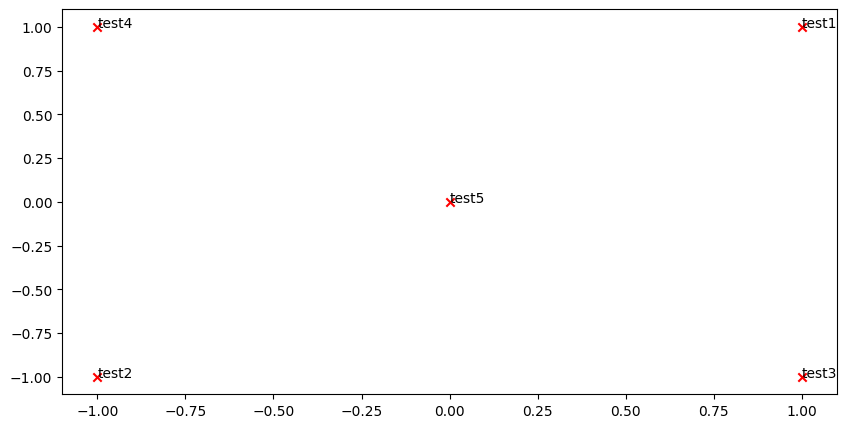

--------------------------------------------------------------------------------


In [27]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# The plot produced should look like the included file question_1.4_test.png 
# ---------------------

print ("-" * 80)
print ("Outputted Plot:")

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]])
word2ind_plot_test = {'test1': 0, 'test2': 1, 'test3': 2, 'test4': 3, 'test5': 4}
words = ['test1', 'test2', 'test3', 'test4', 'test5']
plot_embeddings(M_reduced_plot_test, word2ind_plot_test, words)

print ("-" * 80)

### 题目 1.5：共现图分析 [书面]（3 分）

下面将把你写的各部分串起来！我们将在 Large Movie Review 语料上、用固定窗口 4（默认窗口大小）计算共现矩阵，再用 TruncatedSVD 得到每个词的二维嵌入。TruncatedSVD 返回 U*S，因此需要对返回的向量做归一化，使所有向量落在单位圆附近（此时“接近”表示方向上的接近）。**注意**：下面做归一化的那行代码用到了 NumPy 的 *broadcasting*，若不熟悉可参阅 [Jake VanderPlas：数组运算与广播](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html)。

运行下面单元格生成图像，可能需要几分钟。

Running Truncated SVD over 5880 words...
Done.


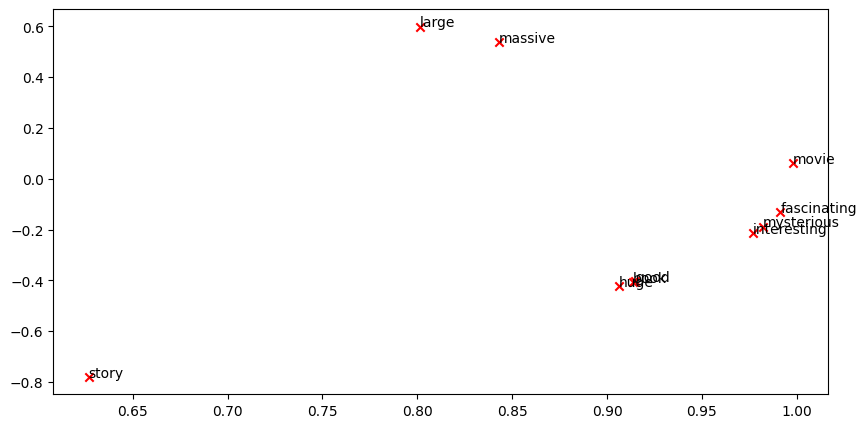

In [28]:
# -----------------------------
# Run This Cell to Produce Your Plot
# ------------------------------
imdb_corpus = read_corpus()
M_co_occurrence, word2ind_co_occurrence = compute_co_occurrence_matrix(imdb_corpus)
M_reduced_co_occurrence = reduce_to_k_dim(M_co_occurrence, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced_co_occurrence, axis=1)
M_normalized = M_reduced_co_occurrence / M_lengths[:, np.newaxis] # broadcasting

words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_normalized, word2ind_co_occurrence, words)

**请确认你的图与作业压缩包中的 "question_1.5.png" 一致。若不一致，请以 "question_1.5.png" 中的图回答下面两问。**

a. 在二维嵌入空间中找到至少两组聚在一起的词，并分别解释你观察到的每一组。

#### <font color="red">在此作答。</font>
1."large""massive"
2."interesting""fascinating"


b. 有哪些你本以为会聚在一起却没有？请至少举两例说明。

#### <font color="red">在此作答。</font>
1.story 和movie吧，感觉上挺相似的啊

## 第二部分：基于预测的词向量（15 分）

如课上所述，近年来基于预测的词向量（如 word2vec 和 GloVe，后者也利用了计数信息）表现更好。这里我们将使用 GloVe 得到的嵌入。更多关于 word2vec 与 GloVe 的细节请复习课堂笔记与讲义。若有兴趣，可尝试阅读 [GloVe 原论文](https://nlp.stanford.edu/pubs/glove.pdf)。

然后运行下面单元格将 GloVe 向量加载到内存。**注意**：若是首次运行（即需下载嵌入模型），可能需要几分钟；若之前已运行过，再次运行只会加载模型而不会重新下载，大约需要 1–2 分钟。

In [5]:
def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each length 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin
wv_from_bin = load_embedding_model()

KeyboardInterrupt: 

#### 注意：若出现 "reset by peer" 错误，请重新运行该单元格以重新开始下载。 

### 词嵌入的降维
下面直接比较 GloVe 嵌入与共现矩阵得到的嵌入。为避免内存不足，我们只使用 40000 个 GloVe 向量的子集。
请运行下面单元格：

1. 将 40000 个 GloVe 向量放入矩阵 M
2. 运行 `reduce_to_k_dim`（你的 Truncated SVD 函数），将向量从 200 维降到 2 维。

In [56]:
def get_matrix_of_vectors(wv_from_bin, required_words):
    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """
    import random
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in words:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind

In [ ]:
# -----------------------------------------------------------------
# Run Cell to Reduce 200-Dimensional Word Embeddings to k Dimensions
# Note: This should be quick to run
# -----------------------------------------------------------------
M, word2ind = get_matrix_of_vectors(wv_from_bin, words)
M_reduced = reduce_to_k_dim(M, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis] # broadcasting

**注意：若本机出现内存不足，可尝试关闭其他程序以释放内存，或重启电脑后再立即打开并运行 Jupyter notebook，看是否能正确加载词向量。若仍无法在本地加载嵌入，请到答疑时间或联系课程助教。**

### 题目 2.1：GloVe 图分析 [书面]（3 分）

运行下面单元格，绘制 `['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']` 的二维 GloVe 嵌入。

In [ ]:
words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_reduced_normalized, word2ind, words)

**请确认你的图与作业压缩包中的 "question_2.1.png" 一致。若不一致，请以 "question_2.1.png"（以及若适用，"question_1.5.png"）中的图回答下面两问。**

a. 该图与之前由共现矩阵得到的图相比，有什么不同？有什么相似之处？各举一点。

#### <font color="red">在此作答。</font>

b. 为什么 GloVe 的图（question_2.1.png）可能与共现矩阵得到的图（question_1.5.png）不同？

#### <font color="red">在此作答。</font>

### 余弦相似度
有了词向量之后，需要一种方式根据这些向量度量词与词之间的相似度，其中之一是余弦相似度。我们将用它来找出彼此“接近”或“远离”的词。

可以把 n 维向量看作 n 维空间中的点。[L1](http://mathworld.wolfram.com/L1-Norm.html)、[L2](http://mathworld.wolfram.com/L2-Norm.html) 距离可度量两点之间“要走过”的空间大小。另一种做法是看两向量之间的夹角。由三角关系可知：

<img src="./imgs/inner_product.png" width=20% style="float: center;"></img>

不必算出角度本身，可以用 $similarity = cos(\Theta)$ 表示相似度。形式化地，两向量 $p$、$q$ 的 [余弦相似度](https://en.wikipedia.org/wiki/Cosine_similarity) $s$ 定义为：

$$s = \frac{p \cdot q}{||p|| ||q||}, \textrm{ where } s \in [-1, 1] $$ 

### 题目 2.2：多义词 [代码 + 书面]（1.5 分）
多义词（polyseme）与同形异义词（homonym）都有多种含义（区别见 [维基](https://en.wikipedia.org/wiki/Polysemy)）。请找一个*至少有两种不同含义*的词，使得按余弦相似度排名的前 10 个最相似词中，同时包含*两种*含义下的相关词。例如 "leaves" 在前 10 中既有“离开”又有“植物结构”相关词，"scoop" 既有“蛋筒”又有“内幕”相关词。你可能需要多试几个多义/同形词才能找到。

请写出你找到的词以及前 10 中出现的多种含义。你认为为什么很多你试过的多义/同形词不满足条件（即前 10 最相似词只包含该词**一种**含义）？

**注意**：请使用 `wv_from_bin.most_similar(word)` 获取前 10 最相似词。该函数按与给定词余弦相似度对词表中其余词排序。更多用法见 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.most_similar)__。

In [ ]:
# ------------------
# Write your implementation here.


# ------------------

#### <font color="red">在此作答。</font>

### 题目 2.3：同义词与反义词（2 分）[代码 + 书面]

在考虑余弦相似度时，用余弦距离往往更方便，其定义为 1 - 余弦相似度。

请找三个词 $(w_1,w_2,w_3)$，其中 $w_1$ 与 $w_2$ 为同义词、$w_1$ 与 $w_3$ 为反义词，但满足 余弦距离 $(w_1,w_3) <$ 余弦距离 $(w_1,w_2)$。

例如 $w_1$="happy" 与 $w_3$="sad" 的距离小于与 $w_2$="cheerful" 的距离。请另找一个满足条件的例子，并简要解释为何会出现这种反直觉的结果。

请使用 `wv_from_bin.distance(w1, w2)` 计算两词之间的余弦距离。更多用法见 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.distance)__。

In [ ]:
# ------------------
# Write your implementation here.


# ------------------

#### <font color="red">在此作答。</font>

### 题目 2.4：词向量类比 [书面]（1.5 分）
词向量*有时*能体现类比关系。

例如类比「man : grandfather :: woman : x」（即 man 对 grandfather 相当于 woman 对 x），x 是什么？

下面单元格演示如何用 __[GenSim 文档](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar)__ 中的 `most_similar` 结合词向量求 x。该函数会找出与 `positive` 中词最相似、与 `negative` 中词最不相似的词（并会排除输入词本身，因其往往最相似；见 [该论文](https://www.aclweb.org/anthology/N18-2039.pdf)）。类比答案即为余弦相似度最高（返回值最大）的词。

In [ ]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

记 $m$、$g$、$w$、$x$ 分别为 `man`、`grandfather`、`woman` 与答案的词向量。在答案中**仅**使用向量 $m$、$g$、$w$ 以及向量运算 $+$、$-$，写出我们与 $x$ 做余弦相似度最大化的那个表达式。

提示：词向量即表示词的多维向量。可在二维平面上随意标出各向量的位置画个草图：`man` 和 `woman` 相对于 `grandfather` 和答案应分别在什么位置？

#### <font color="red">在此作答。</font>

### 题目 2.5：寻找类比 [代码 + 书面]（1.5 分）
a. 上例中显然 "grandmother" 完成该类比。请直观解释为什么 `most_similar` 还会给出 "granddaughter"、"daughter" 或 "mother" 等词？

#### <font color="red">在此作答。</font>

b. 找一个在这些向量下成立的类比（即期望的词排在第一）。答案中请用 x:y :: a:b 的形式写出完整类比。若类比较复杂，用一两句话说明为何成立。

**注意**：可能需要多试几个类比才能找到一个成立的。

In [ ]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.


# ------------------

# Test the solution
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] == b

#### <font color="red">在此作答。</font>

### 题目 2.6：不成立的类比 [代码 + 书面]（1.5 分）
a. 下面我们期望得到类比 "hand : glove :: foot : **sock**"，但实际结果并非如此。请给出一个可能的原因解释为何该类比会得到这样的结果。

In [ ]:
pprint.pprint(wv_from_bin.most_similar(positive=['foot', 'glove'], negative=['hand']))

#### <font color="red">在此作答。</font>

b. 再找一个在这些向量下*不*成立的类比。答案中请用 x:y :: a:b 写出期望的类比，并写出词向量给出的**错误**的 b 值（上例中即为 **'45,000-square'**）。

In [ ]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.


# ------------------
pprint.pprint(wv_from_bin.most_similar(positive=[a, y], negative=[x]))
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] != b

#### <font color="red">在此作答。</font>

### 题目 2.7：词向量偏见的引导分析 [书面]（1 分）

认识词嵌入中隐含的偏见（性别、种族、性取向等）很重要。偏见可能通过使用这些模型的应用强化刻板印象，从而带来危害。

运行下面单元格，查看 (a) 与 "man" 和 "profession" 最相似、与 "woman" 最不相似的词，以及 (b) 与 "woman" 和 "profession" 最相似、与 "man" 最不相似的词。指出与女性相关的词列表和与男性相关的词列表之间的差异，并说明其如何反映性别偏见。

In [ ]:
# Run this cell
# Here `positive` indicates the list of words to be similar to and `negative` indicates the list of words to be
# most dissimilar from.

pprint.pprint(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))

#### <font color="red">在此作答。</font>

### 题目 2.8：词向量偏见的独立分析 [代码 + 书面]（1 分）

使用 `most_similar` 再找一对能体现向量中某种偏见的类比。请简要说明你发现的偏见例子。

In [ ]:
# ------------------
# Write your implementation here.


# ------------------

#### <font color="red">在此作答。</font>

### 题目 2.9：关于偏见的思考 [书面]（2 分）

a. 请给出一种可能的解释：偏见是如何进入词向量的。解释应围绕词向量本身，而非其他 AI 系统（如 ChatGPT）中的偏见。必要时可举具体历史例子说明。

#### <font color="red">在此作答。</font>

b. 请举出一种可用来减轻词向量所表现偏见的方法，并简要说明该方法及其目标。


#### <font color="red">在此作答。</font>

# <font color="blue"> 提交说明</font>

1. 点击 Jupyter Notebook 顶部的保存按钮。
2. 选择 Edit -> Clear Outputs of All Cells，会清除所有单元格的输出（但保留所有单元格内容）。
3. 选择 Run -> Run All Cells，按顺序运行所有单元格，可能需要几分钟。
4. 运行完成后，选择 File -> Save and Export Notebook as -> PDF（若出现 <font color="red">"nbconvert failed: Pandoc wasn't found"</font> 等错误，可先导出为 HTML：File -> Save and Export Notebook as -> HTML，将 notebook 存为 HTML 后，在浏览器中打开该 HTML，按 Ctrl + P（Windows/Linux）或 Cmd + P（Mac）打开打印对话框，在对话框中选择“另存为 PDF”并保存）。<font color='blue'> 请确保 PDF 中包含了你的所有作答，尤其是代码部分</font>；若提供的示例代码因未换行而被截断可以接受。
5. 打开生成的 PDF 检查一遍，确认所有作答都正确显示。评阅人只会看到你的 PDF！
6. 在 Gradescope 上提交该 PDF。